In [6]:
!huggingface-cli login


    _|    _|  _|    _|    _|_|_|    _|_|_|  _|_|_|  _|      _|    _|_|_|      _|_|_|_|    _|_|      _|_|_|  _|_|_|_|
    _|    _|  _|    _|  _|        _|          _|    _|_|    _|  _|            _|        _|    _|  _|        _|
    _|_|_|_|  _|    _|  _|  _|_|  _|  _|_|    _|    _|  _|  _|  _|  _|_|      _|_|_|    _|_|_|_|  _|        _|_|_|
    _|    _|  _|    _|  _|    _|  _|    _|    _|    _|    _|_|  _|    _|      _|        _|    _|  _|        _|
    _|    _|    _|_|      _|_|_|    _|_|_|  _|_|_|  _|      _|    _|_|_|      _|        _|    _|    _|_|_|  _|_|_|_|

    To log in, `huggingface_hub` requires a token generated from https://huggingface.co/settings/tokens .
Enter your token (input will not be visible): 
Add token as git credential? (Y/n) n
Token is valid (permission: fineGrained).
The token `adda` has been saved to /root/.cache/huggingface/stored_tokens
Your token has been saved to /root/.cache/huggingface/token
Login successful.
The current active token is: `adda`


In [ ]:
!pip install -U datasets
!pip install librosa soundfile
!pip install numpy==2.2.0

In [2]:
import numpy
numpy.version.version

'2.2.0'

# Load 1 parquet file

In [ ]:
from datasets import load_dataset

In [ ]:
train_url = "https://huggingface.co/datasets/linhtran92/viet_bud500/resolve/main/data/train-00000-of-00105-be5f872f8be772f5.parquet"

In [ ]:
data_files = {"train": [train_url]}
dataset = load_dataset("parquet", data_files=data_files)

(…)-00000-of-00105-be5f872f8be772f5.parquet:   0%|          | 0.00/492M [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

# Load all "train" parquet files

In [1]:
import glob
from datasets import load_dataset

# Step 1: Find all .parquet files starting with "train" in the local directory
train_files = sorted(glob.glob("../viet_bud500/data/train-*.parquet"))

print("Found files:")
for f in train_files:
    print(f)

f:\vietbud500\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Found files:
../viet_bud500/data\train-00000-of-00105-be5f872f8be772f5.parquet
../viet_bud500/data\train-00001-of-00105-8ca67a58a0cae4cb.parquet
../viet_bud500/data\train-00002-of-00105-2861e89b23f819d1.parquet
../viet_bud500/data\train-00003-of-00105-4a1a98f2c3a19128.parquet
../viet_bud500/data\train-00004-of-00105-67eda106ef3ab6f2.parquet
../viet_bud500/data\train-00005-of-00105-c2b2ed52d5d7af18.parquet
../viet_bud500/data\train-00006-of-00105-c24ceb31a7177841.parquet
../viet_bud500/data\train-00007-of-00105-267684023bcc42f5.parquet
../viet_bud500/data\train-00008-of-00105-39acf3878d2758e3.parquet
../viet_bud500/data\train-00009-of-00105-562f815d89486481.parquet
../viet_bud500/data\train-00010-of-00105-a73b5714e32083cf.parquet
../viet_bud500/data\train-00011-of-00105-07e6b3c85fa8f716.parquet
../viet_bud500/data\train-00012-of-00105-255d074fa5b7727f.parquet
../viet_bud500/data\train-00013-of-00105-d3a7101691ecb9c6.parquet
../viet_bud500/data\train-00014-of-00105-18cd935a4e790256.parqu

In [2]:
# Step 2: Prepare the data_files dictionary
data_files = {"train": train_files}

# Step 3: Load the dataset
dataset = load_dataset("parquet", data_files=data_files, cache_dir="./.hf_cache")

# Optional: check number of splits and total rows
print(dataset)

Generating train split: 634158 examples [05:14, 2014.73 examples/s]


DatasetDict({
    train: Dataset({
        features: ['audio', 'transcription'],
        num_rows: 634158
    })
})


# Start statistic

In [3]:
print(dataset)

DatasetDict({
    train: Dataset({
        features: ['audio', 'transcription'],
        num_rows: 634158
    })
})


In [4]:
train_dataset = dataset["train"]
print(train_dataset)

Dataset({
    features: ['audio', 'transcription'],
    num_rows: 634158
})


In [5]:
train_dataset[0]

{'audio': {'path': None,
  'array': array([ 0.04827881,  0.08624268,  0.08853149, ..., -0.08074951,
         -0.08364868, -0.08636475], shape=(34920,)),
  'sampling_rate': 16000},
 'transcription': 'thế mà hôm nay lại nghe em gái nhắc đến'}

Duration Summary (in seconds):
count    634158.000000
mean          2.562557
std           0.649578
min           0.628687
25%           2.114750
50%           2.501375
75%           2.941688
90%           3.382875
95%           3.700875
99%           4.418822
max          16.031125
dtype: float64


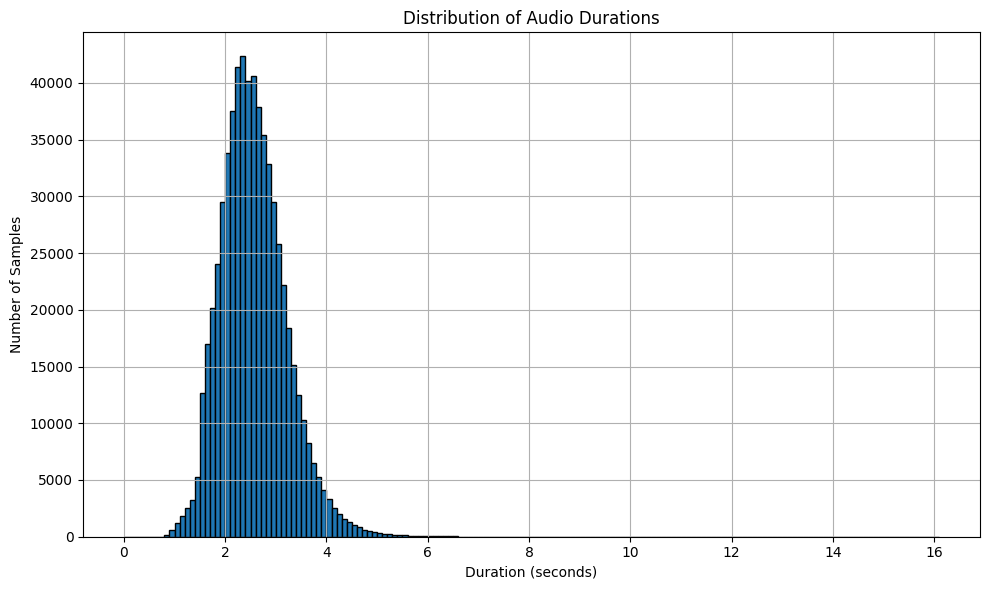

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Step 1: Compute duration for each audio sample (in seconds)
durations = [len(sample['audio']['array']) / sample['audio']['sampling_rate'] for sample in train_dataset]

# Step 2: Convert to numpy array for analysis
durations = np.array(durations)

# Step 3: Create a summary table with percentiles
summary = pd.Series(durations).describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99])
print("Duration Summary (in seconds):")
print(summary)

# Step 4: Plot histogram
plt.figure(figsize=(10, 6))
bins = np.arange(0, durations.max() + 0.1, 0.1)  # bin size = 0.1s
plt.hist(durations, bins=bins, edgecolor='black')
plt.title("Distribution of Audio Durations")
plt.xlabel("Duration (seconds)")
plt.ylabel("Number of Samples")
plt.grid(True)
plt.tight_layout()
plt.show()